# Surface Code Memory Experiment with Unified Circuit Generation

This notebook demonstrates the complete surface code experiment workflow using PECOS's
unified circuit generation abstraction.

**Key concept**: A single `SurfacePatch` geometry is used to generate circuits in
multiple formats:
- **Guppy**: Type-safe quantum DSL for HUGR compilation
- **Stim**: Industry-standard format for QEC simulation
- **TickCircuit**: PECOS native format with explicit tick boundaries
- **DagCircuit**: PECOS native format for analysis

All representations are guaranteed to be structurally equivalent since they derive
from the same abstract circuit definition.

In [ ]:
# Core circuit generation from unified abstraction
import json as json_module

# Guppy/HUGR compilation
from pecos.compilation_pipeline import compile_guppy_to_hugr
from pecos.guppy.surface import generate_surface_code_module, get_num_qubits, make_surface_code

# PECOS native DEM builder
from pecos.qec import DagFaultAnalyzer, DemBuilder
from pecos.qec.surface import (
    SurfacePatch,
    generate_dag_circuit_from_patch,
    # DEM generation methods
    generate_dem_from_tick_circuit,
    # Circuit generators - all use SurfacePatch as input
    generate_guppy_from_patch,
    generate_stim_from_patch,
    generate_tick_circuit_from_patch,
    plot_surface_code,
)
from pecos.qec.surface.circuit_builder import _extract_measurement_order

# Selene execution
from selene_sim import IdealErrorModel, SimpleRuntime, Stim, build

In [2]:
# Experiment parameters
NUM_ROUNDS = 3
NUM_SHOTS = 10
BASIS = "Z"

# Noise parameters (for DEM generation)
P1 = 4e-5       # Single-qubit gate error
P2 = 1e-3       # Two-qubit gate error
P_MEAS = 4e-4   # Measurement error
P_PREP = 4e-4   # Initialization error

## Unified Circuit Generation

The key abstraction is `SurfacePatch`, which encapsulates the surface code geometry.
From a single patch, we can generate circuits in any supported format.

=== SurfacePatch Geometry ===
Distance: 3
Data qubits: 9
X stabilizers: 4
Z stabilizers: 4


/tmp/ipykernel_3629674/4043462062.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


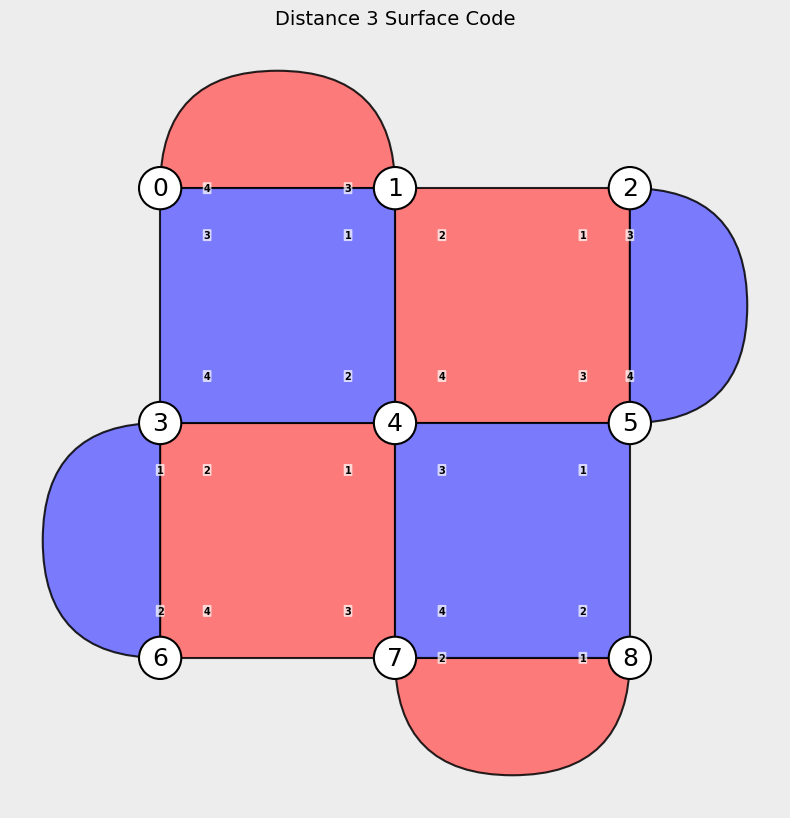

In [3]:
# Create a distance-3 surface code patch
patch = SurfacePatch.create(distance=3)

print("=== SurfacePatch Geometry ===")
print(f"Distance: {patch.distance}")
print(f"Data qubits: {patch.geometry.num_data}")
print(f"X stabilizers: {len(patch.geometry.x_stabilizers)}")
print(f"Z stabilizers: {len(patch.geometry.z_stabilizers)}")

# Visualize the patch
fig, ax = plot_surface_code(3, show_cnot_order=True)
ax.set_title("Distance 3 Surface Code", fontsize=14, pad=10)
fig.show()

### Generate Multiple Circuit Formats

From the same `SurfacePatch`, we generate structurally equivalent circuits:

In [4]:
# Generate all formats from the same patch
print("Generating circuits from SurfacePatch...")
print()

# 1. Guppy source code (for HUGR compilation and Selene execution)
guppy_source = generate_guppy_from_patch(patch, NUM_ROUNDS, BASIS)
print(f"1. Guppy source: {len(guppy_source)} chars")
print("   Functions: prep_z_basis, prep_x_basis, syndrome_extraction, measure_z_basis, ...")
print()

# 2. Stim circuit (for Stim simulation and DEM generation)
stim_circuit = generate_stim_from_patch(patch, NUM_ROUNDS, BASIS, p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP)
stim_lines = stim_circuit.strip().split("\n")
print(f"2. Stim circuit: {len(stim_lines)} lines")
print(f"   Preview: {stim_lines[0]}")
print()

# 3. TickCircuit (PECOS native format with explicit tick boundaries)
tick_circuit = generate_tick_circuit_from_patch(patch, NUM_ROUNDS, BASIS)
print(f"3. TickCircuit: {tick_circuit.num_ticks()} ticks, {tick_circuit.gate_count()} gates")
print("   Metadata: detectors, observables, num_measurements")
print()

# 4. DagCircuit (PECOS native format for fault analysis)
dag_circuit = generate_dag_circuit_from_patch(patch, NUM_ROUNDS, BASIS)
print(f"4. DagCircuit: {dag_circuit.gate_count()} gates")
print()

print("All formats derive from the same abstract circuit definition,")
print("ensuring structural equivalence.")

Generating circuits from SurfacePatch...

1. Guppy source: 4400 chars
   Functions: prep_z_basis, prep_x_basis, syndrome_extraction, measure_z_basis, ...

2. Stim circuit: 399 lines
   Preview: # Surface code d=3 Z-basis memory experiment

3. TickCircuit: 26 ticks, 162 gates
   Metadata: detectors, observables, num_measurements

4. DagCircuit: 162 gates

All formats derive from the same abstract circuit definition,
ensuring structural equivalence.


## Selene Execution via Guppy/HUGR

The Guppy code is compiled to HUGR (Hierarchical Unified Quantum Representation),
then executed with Selene using the Stim backend.

In [5]:
# View Guppy source (first 50 lines)
distance = 3
source = generate_surface_code_module(distance)
lines = source.split("\n")
print("\n".join(lines[:50]))
print(f"\n... ({len(lines) - 50} more lines)")

"""Surface code patch (dx=3, dz=3) implementation in Guppy.

Auto-generated from SurfacePatch geometry.

Data qubits: 9
X stabilizers: 4
Z stabilizers: 4
Ancilla qubits: 8 (one per stabilizer)
"""

from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import cx, discard, h, measure, measure_array, qubit, x


@guppy.struct
class SurfaceCode_3x3:
    """Surface code patch with dx=3, dz=3 (9 data qubits)."""

    data: array[qubit, 9]


@guppy.struct
class Syndrome_3x3:
    """Syndrome for dx=3, dz=3 patch."""

    synx: array[bool, 4]
    synz: array[bool, 4]


# === State Preparation ===

@guppy
def prep_z_basis() -> SurfaceCode_3x3:
    """Prepare logical |0_L> state."""
    data = array(qubit() for _ in range(9))
    return SurfaceCode_3x3(data)


@guppy
def prep_x_basis() -> SurfaceCode_3x3:
    """Prepare logical |+_L> state."""
    data = array(qubit() for _ in range(9))
    for i in range(9):
        h(data[i])
    return Su

In [6]:
num_data = distance * distance
num_stab = (num_data - 1) // 2
num_qubits = get_num_qubits(distance)
print(f"Patch: dx={distance}, dz={distance}")
print(f"Data qubits: {num_data}, X stabilizers: {num_stab}, Z stabilizers: {num_stab}")
print(f"Total qubits (data + ancilla): {num_qubits}")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

instance = build(hugr_bytes, name=f"surface_d{distance}")
print("Built selene instance.")

Patch: dx=3, dz=3
Data qubits: 9, X stabilizers: 4, Z stabilizers: 4
Total qubits (data + ancilla): 17


HUGR size: 299844 bytes


Built selene instance.


In [7]:
for shot_idx, shot_results in enumerate(
    instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=NUM_SHOTS,
        error_model=IdealErrorModel(),
        runtime=SimpleRuntime(),
        n_processes=1,
    ),
):
    results = list(shot_results)
    if shot_idx < 3:
        print(f"Shot {shot_idx}:")
        for name, values in results:
            print(f"  {name}: {values}")
    elif shot_idx == 3:
        print(f"... ({NUM_SHOTS - 3} more shots omitted)")

Shot 0:
  synx: [1, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [1, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [1, 1, 1, 0]
  synz: [0, 0, 0, 0]
  final: [0, 1, 1, 1, 0, 1, 1, 1, 0]
Shot 1:
  synx: [0, 1, 0, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 0, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 0, 0]
  synz: [0, 0, 0, 0]
  final: [0, 1, 1, 0, 1, 1, 0, 0, 0]
Shot 2:
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  final: [1, 1, 0, 1, 1, 0, 1, 0, 1]
... (7 more shots omitted)


## Scaling: Distance 5 and 7

The same workflow scales to larger distances. HUGR and Selene handle the
increased circuit complexity automatically.

/tmp/ipykernel_3629674/768798676.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


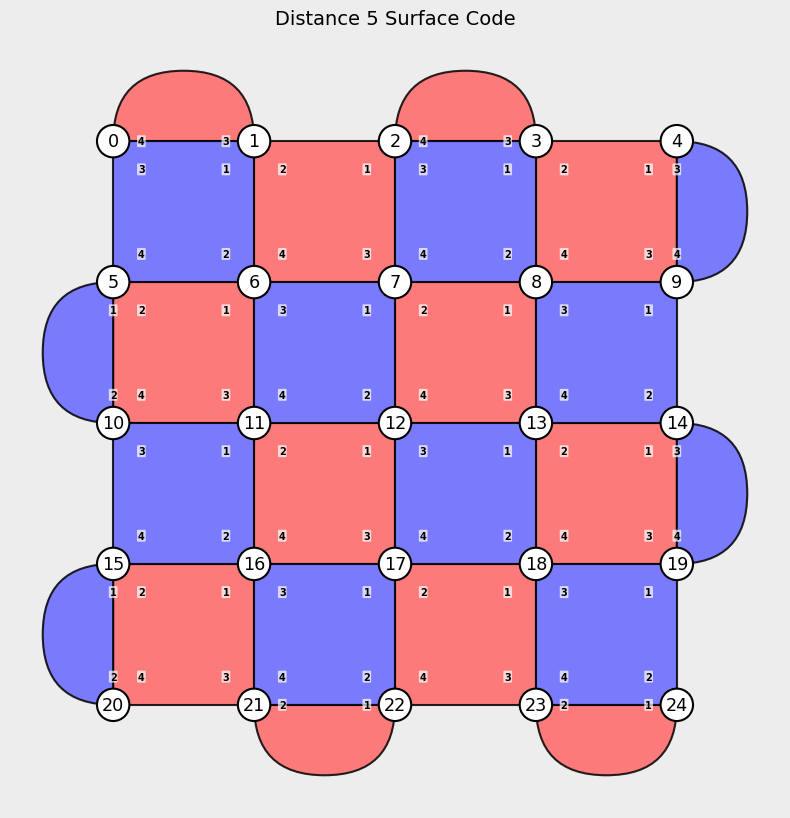

In [8]:
# Visualize distance 5
fig, ax = plot_surface_code(5, show_cnot_order=True)
ax.set_title("Distance 5 Surface Code", fontsize=14, pad=10)
fig.show()

In [9]:
# Build and run distance 5
distance = 5
num_data = distance * distance
num_stab = (num_data - 1) // 2
num_qubits = get_num_qubits(distance)
print(f"Patch: dx={distance}, dz={distance}")
print(f"Data qubits: {num_data}, X stabilizers: {num_stab}, Z stabilizers: {num_stab}")
print(f"Total qubits (data + ancilla): {num_qubits}")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

instance = build(hugr_bytes, name=f"surface_d{distance}")
print("Built selene instance.")

Patch: dx=5, dz=5
Data qubits: 25, X stabilizers: 12, Z stabilizers: 12
Total qubits (data + ancilla): 49


HUGR size: 465780 bytes


Built selene instance.


In [10]:
# Run Selene for distance 5
for shot_idx, shot_results in enumerate(
    instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=NUM_SHOTS,
        error_model=IdealErrorModel(),
        runtime=SimpleRuntime(),
        n_processes=1,
    ),
):
    results = list(shot_results)
    if shot_idx < 2:
        print(f"Shot {shot_idx}:")
        for name, values in results:
            print(f"  {name}: {values}")
    elif shot_idx == 2:
        print(f"... ({NUM_SHOTS - 2} more shots omitted)")

Shot 0:
  synx: [0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  final: [1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0]
Shot 1:
  synx: [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  final: [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0]
... (8 more shots omitted)


In [11]:
# Distance 7 - show compilation (execution takes longer)
distance = 7
num_qubits = get_num_qubits(distance)
print(f"Distance {distance}: {distance*distance} data qubits, {num_qubits} total qubits")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

# Note: Execution at larger distances works but takes more time
# instance = build(hugr_bytes, name=f"surface_d{distance}")
# instance.run_shots(...)

Distance 7: 49 data qubits, 97 total qubits


HUGR size: 726458 bytes


## Native PECOS DEM Generation

PECOS provides native DEM generation that works directly with TickCircuit,
without requiring Stim as an intermediate step. The workflow is:

1. `SurfacePatch` -> `TickCircuit` (with detector/tracked-Pauli metadata)
2. `TickCircuit` -> `DagCircuit` -> `DagFaultAnalyzer` -> `DemBuilder`
3. `DemBuilder` -> DEM string (Stim-compatible format)

This native path provides:
- Tighter integration with PECOS circuit representations
- Access to fault propagation analysis internals
- No external dependencies for DEM generation

In [ ]:
import re
from typing import TYPE_CHECKING

import stim
from pecos.qec.surface import SurfacePatch

if TYPE_CHECKING:
    from pecos_rslib.qec import DetectorErrorModel


def generate_pecos_dem(
    patch: SurfacePatch,
    num_rounds: int,
    basis: str,
    p1: float,
    p2: float,
    p_meas: float,
    p_prep: float,
) -> "DetectorErrorModel":
    """Generate DEM using PECOS native fault propagation.

    This is the recommended PECOS-native approach that doesn't require Stim.
    """
    # Generate TickCircuit with full metadata
    tc = generate_tick_circuit_from_patch(patch, num_rounds=num_rounds, basis=basis)

    # Convert to DAG and build influence map
    dag = tc.to_dag_circuit()
    analyzer = DagFaultAnalyzer(dag)
    influence_map = analyzer.build_influence_map()

    # Extract metadata from TickCircuit
    detectors_json = tc.get_meta("detectors")
    observables_json = tc.get_meta("observables")
    num_measurements = int(tc.get_meta("num_measurements") or "0")
    measurement_order = _extract_measurement_order(tc)

    # Build DEM using Rust DemBuilder
    builder = DemBuilder(influence_map)
    builder.with_noise(p1, p2, p_meas, p_prep)
    builder.with_num_measurements(num_measurements)
    builder.with_measurement_order(measurement_order)
    builder.with_detectors_json(detectors_json)
    if observables_json:
        builder.with_tracked_paulis_json(observables_json)

    return builder.build()

### Comparing DEM Generation Methods

We can generate DEMs using either:
1. **Via Stim**: Generate Stim circuit, use Stim's DEM generator
2. **Native PECOS**: Use `DemBuilder` with TickCircuit metadata

In [ ]:
# Generate DEMs using both methods for distance 3
patch = SurfacePatch.create(distance=3)

# Method 1: Via Stim (for reference)
noisy_stim = generate_stim_from_patch(
    patch, num_rounds=NUM_ROUNDS, basis=BASIS,
    p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP,
)
circuit = stim.Circuit(noisy_stim)
stim_dem = circuit.detector_error_model(decompose_errors=True)
stim_dem_str = str(stim_dem)
stim_error_count = len([line for line in stim_dem_str.split("\n") if line.strip().startswith("error(")])

print("=== Stim-generated DEM (distance 3, decomposed) ===")
print(f"Detectors: {stim_dem.num_detectors}")
print(f"Observables: {stim_dem.num_observables}")
print(f"Error mechanisms: {stim_error_count}")

# Method 2: Native PECOS
pecos_dem = generate_pecos_dem(
    patch, num_rounds=NUM_ROUNDS, basis=BASIS,
    p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP,
)
pecos_raw_str = pecos_dem.to_string()
pecos_decomp_str = pecos_dem.to_string_decomposed()
pecos_raw_count = len([line for line in pecos_raw_str.split("\n") if line.strip().startswith("error(")])
pecos_decomp_count = len([line for line in pecos_decomp_str.split("\n") if line.strip().startswith("error(")])

print()
print("=== PECOS-native DEM (distance 3) ===")
print(f"Detectors: {pecos_dem.num_detectors}")
print(f"Observables: {pecos_dem.num_observables}")
print(f"Error mechanisms (raw): {pecos_raw_count}")
print(f"Error mechanisms (decomposed): {pecos_decomp_count}")
print()
print("=== Comparison ===")
print(f"Stim decomposed:  {stim_error_count} error mechanisms")
print(f"PECOS decomposed: {pecos_decomp_count} error mechanisms")
print(f"PECOS raw:        {pecos_raw_count} error mechanisms")

In [ ]:
# Preview both DEMs (using decomposed format for MWPM decoder compatibility)
print("=== Stim DEM (first 10 error lines) ===")
for line in str(stim_dem).split("\n")[:10]:
    print(f"  {line}")

print()
print("=== PECOS DEM decomposed (first 10 error lines) ===")
pecos_decomposed = pecos_dem.to_string_decomposed()
error_lines = [err_line for err_line in pecos_decomposed.split("\n") if err_line.startswith("error(")]
for line in error_lines[:10]:
    print(f"  {line}")

## Export Full Circuit and DEM Outputs

This section prints and saves the complete Guppy, Stim circuit, and DEM outputs
for reference and external use. Files are saved to `examples/surface_code_circuits/`.

**Generated configurations:**
- Distance 3, 5, and 7
- Z-basis and X-basis memory experiments
- PECOS and Stim DEMs (raw and decomposed)

In [15]:
from pathlib import Path

# Create output directory for generated circuit files
output_dir = Path("surface_code_circuits")
output_dir.mkdir(exist_ok=True)

# Generate outputs for all configurations
configs = [
    (3, "Z"),
    (3, "X"),
    (5, "Z"),
    (5, "X"),
    (7, "Z"),
    (7, "X"),
]

all_outputs = {}

for distance, basis in configs:
    key = f"d{distance}_{basis.lower()}"
    patch = SurfacePatch.create(distance=distance)

    # Generate Guppy source (same for both bases)
    guppy_full = generate_surface_code_module(distance)

    # Generate Stim circuit (with noise)
    stim_full = generate_stim_from_patch(
        patch, num_rounds=NUM_ROUNDS, basis=basis,
        p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP,
    )

    # Generate PECOS DEMs (raw and decomposed)
    pecos_dem_obj = generate_pecos_dem(
        patch, num_rounds=NUM_ROUNDS, basis=basis,
        p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP,
    )
    pecos_dem_raw = pecos_dem_obj.to_string()
    pecos_dem_decomposed = pecos_dem_obj.to_string_decomposed()

    # Generate Stim DEM
    stim_circuit_obj = stim.Circuit(stim_full)
    stim_dem_raw = str(stim_circuit_obj.detector_error_model(decompose_errors=False))
    stim_dem_decomposed = str(stim_circuit_obj.detector_error_model(decompose_errors=True))

    all_outputs[key] = {
        "guppy": guppy_full,
        "stim": stim_full,
        "pecos_dem_raw": pecos_dem_raw,
        "pecos_dem_decomposed": pecos_dem_decomposed,
        "stim_dem_raw": stim_dem_raw,
        "stim_dem_decomposed": stim_dem_decomposed,
        "distance": distance,
        "basis": basis,
    }

    print(f"Generated d={distance}, {basis}-basis:")
    print(f"  Guppy: {len(guppy_full)} chars")
    print(f"  Stim circuit: {len(stim_full.splitlines())} lines")
    print(f"  PECOS DEM raw: {len(pecos_dem_raw.splitlines())} lines")
    print(f"  PECOS DEM decomposed: {len(pecos_dem_decomposed.splitlines())} lines")
    print(f"  Stim DEM raw: {len(stim_dem_raw.splitlines())} lines")
    print(f"  Stim DEM decomposed: {len(stim_dem_decomposed.splitlines())} lines")
    print()

print(f"Noise parameters: p1={P1}, p2={P2}, p_meas={P_MEAS}, p_prep={P_PREP}")
print(f"Syndrome rounds: {NUM_ROUNDS}")

Generated d=3, Z-basis:
  Guppy: 4400 chars
  Stim circuit: 399 lines
  PECOS DEM raw: 246 lines
  PECOS DEM decomposed: 292 lines
  Stim DEM raw: 245 lines
  Stim DEM decomposed: 314 lines

Generated d=3, X-basis:
  Guppy: 4400 chars
  Stim circuit: 435 lines
  PECOS DEM raw: 244 lines
  PECOS DEM decomposed: 290 lines
  Stim DEM raw: 243 lines
  Stim DEM decomposed: 322 lines

Generated d=5, Z-basis:
  Guppy: 6942 chars
  Stim circuit: 1135 lines
  PECOS DEM raw: 936 lines
  PECOS DEM decomposed: 1204 lines
  Stim DEM raw: 935 lines
  Stim DEM decomposed: 1105 lines



Generated d=5, X-basis:


  Guppy: 6942 chars
  Stim circuit: 1235 lines
  PECOS DEM raw: 934 lines
  PECOS DEM decomposed: 1202 lines
  Stim DEM raw: 933 lines
  Stim DEM decomposed: 1113 lines



Generated d=7, Z-basis:
  Guppy: 10981 chars
  Stim circuit: 2263 lines
  PECOS DEM raw: 2066 lines
  PECOS DEM decomposed: 2748 lines
  Stim DEM raw: 2065 lines
  Stim DEM decomposed: 2376 lines

Generated d=7, X-basis:
  Guppy: 10981 chars
  Stim circuit: 2459 lines
  PECOS DEM raw: 2064 lines
  PECOS DEM decomposed: 2746 lines
  Stim DEM raw: 2063 lines
  Stim DEM decomposed: 2384 lines

Noise parameters: p1=4e-05, p2=0.001, p_meas=0.0004, p_prep=0.0004
Syndrome rounds: 3


In [16]:
# Print full Guppy source (d=3, same for all bases)
print("=" * 80)
print("GUPPY SOURCE (d=3)")
print("=" * 80)
print(all_outputs["d3_z"]["guppy"])

GUPPY SOURCE (d=3)
"""Surface code patch (dx=3, dz=3) implementation in Guppy.

Auto-generated from SurfacePatch geometry.

Data qubits: 9
X stabilizers: 4
Z stabilizers: 4
Ancilla qubits: 8 (one per stabilizer)
"""

from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import cx, discard, h, measure, measure_array, qubit, x


@guppy.struct
class SurfaceCode_3x3:
    """Surface code patch with dx=3, dz=3 (9 data qubits)."""

    data: array[qubit, 9]


@guppy.struct
class Syndrome_3x3:
    """Syndrome for dx=3, dz=3 patch."""

    synx: array[bool, 4]
    synz: array[bool, 4]


# === State Preparation ===

@guppy
def prep_z_basis() -> SurfaceCode_3x3:
    """Prepare logical |0_L> state."""
    data = array(qubit() for _ in range(9))
    return SurfaceCode_3x3(data)


@guppy
def prep_x_basis() -> SurfaceCode_3x3:
    """Prepare logical |+_L> state."""
    data = array(qubit() for _ in range(9))
    for i in range(9):
        h(dat

In [17]:
# Print Stim circuits for d=3 Z-basis and X-basis
for basis in ["Z", "X"]:
    key = f"d3_{basis.lower()}"
    print("=" * 80)
    print(f"STIM CIRCUIT (d=3, {basis}-basis)")
    print("=" * 80)
    print(all_outputs[key]["stim"])
    print()

STIM CIRCUIT (d=3, Z-basis)
# Surface code d=3 Z-basis memory experiment
# 3 syndrome rounds, 17 qubits

# prep_z_basis
R 0
X_ERROR(0.0004) 0
R 1
X_ERROR(0.0004) 1
R 2
X_ERROR(0.0004) 2
R 3
X_ERROR(0.0004) 3
R 4
X_ERROR(0.0004) 4
R 5
X_ERROR(0.0004) 5
R 6
X_ERROR(0.0004) 6
R 7
X_ERROR(0.0004) 7
R 8
X_ERROR(0.0004) 8
TICK
# syndrome_extraction round 1
R 9
X_ERROR(0.0004) 9
R 10
X_ERROR(0.0004) 10
R 11
X_ERROR(0.0004) 11
R 12
X_ERROR(0.0004) 12
R 13
X_ERROR(0.0004) 13
R 14
X_ERROR(0.0004) 14
R 15
X_ERROR(0.0004) 15
R 16
X_ERROR(0.0004) 16
# Hadamard on X ancillas
H 9
DEPOLARIZE1(4e-05) 9
H 10
DEPOLARIZE1(4e-05) 10
H 11
DEPOLARIZE1(4e-05) 11
H 12
DEPOLARIZE1(4e-05) 12
TICK
# CX round 1
CX 3 13
DEPOLARIZE2(0.001) 3 13
CX 10 2
DEPOLARIZE2(0.001) 10 2
CX 1 14
DEPOLARIZE2(0.001) 1 14
CX 11 4
DEPOLARIZE2(0.001) 11 4
CX 5 15
DEPOLARIZE2(0.001) 5 15
CX 12 8
DEPOLARIZE2(0.001) 12 8
TICK
# CX round 2
CX 6 13
DEPOLARIZE2(0.001) 6 13
CX 10 1
DEPOLARIZE2(0.001) 10 1
CX 4 14
DEPOLARIZE2(0.001) 4 14
CX

In [18]:
# Print PECOS DEMs (raw) for d=3 Z-basis and X-basis
for basis in ["Z", "X"]:
    key = f"d3_{basis.lower()}"
    print("=" * 80)
    print(f"PECOS DEM - RAW (d=3, {basis}-basis)")
    print("=" * 80)
    print(all_outputs[key]["pecos_dem_raw"])
    print()

PECOS DEM - RAW (d=3, Z-basis)
detector(0, 0, 1) D0
detector(1, 0, 1) D1
detector(2, 0, 1) D2
detector(3, 0, 1) D3
detector(0, 0, 2) D4
detector(1, 0, 2) D5
detector(2, 0, 2) D6
detector(3, 0, 2) D7
detector(4, 1, 0) D8
detector(5, 1, 0) D9
detector(6, 1, 0) D10
detector(7, 1, 0) D11
detector(4, 1, 1) D12
detector(5, 1, 1) D13
detector(6, 1, 1) D14
detector(7, 1, 1) D15
detector(4, 1, 2) D16
detector(5, 1, 2) D17
detector(6, 1, 2) D18
detector(7, 1, 2) D19
detector(4, 1, 3) D20
detector(5, 1, 3) D21
detector(6, 1, 3) D22
detector(7, 1, 3) D23
logical_observable L0
error(0.001452) D0
error(0.0004) D0 D1
error(0.000267) D0 D1 D13 L0
error(6.66978e-5) D0 D1 D13 D14
error(0.0002) D0 D1 D13 D17
error(6.66978e-5) D0 D1 D14 D17
error(6.66978e-5) D0 D1 D15 L0
error(6.66978e-5) D0 D1 D15 D17
error(0.0002) D0 D1 D17 L0
error(0.001119) D0 D4
error(0.000267) D0 D4 D17 L0
error(0.0002) D0 D5
error(6.66978e-5) D0 D5 D15 L0
error(6.66978e-5) D0 D5 D15 D17
error(0.0002) D0 D5 D17 L0
error(0.000133) D0

In [19]:
# Print PECOS DEMs (decomposed) for d=3 Z-basis and X-basis
for basis in ["Z", "X"]:
    key = f"d3_{basis.lower()}"
    print("=" * 80)
    print(f"PECOS DEM - DECOMPOSED (d=3, {basis}-basis)")
    print("=" * 80)
    print(all_outputs[key]["pecos_dem_decomposed"])
    print()

PECOS DEM - DECOMPOSED (d=3, Z-basis)
detector(0, 0, 1) D0
detector(1, 0, 1) D1
detector(2, 0, 1) D2
detector(3, 0, 1) D3
detector(0, 0, 2) D4
detector(1, 0, 2) D5
detector(2, 0, 2) D6
detector(3, 0, 2) D7
detector(4, 1, 0) D8
detector(5, 1, 0) D9
detector(6, 1, 0) D10
detector(7, 1, 0) D11
detector(4, 1, 1) D12
detector(5, 1, 1) D13
detector(6, 1, 1) D14
detector(7, 1, 1) D15
detector(4, 1, 2) D16
detector(5, 1, 2) D17
detector(6, 1, 2) D18
detector(7, 1, 2) D19
detector(4, 1, 3) D20
detector(5, 1, 3) D21
detector(6, 1, 3) D22
detector(7, 1, 3) D23
logical_observable L0
error(0.001452) D0
error(0.0004) D0 D1
error(0.000267) D0 D1 ^ D13 L0
error(3.33489e-5) D0 D1 ^ D13 D14
error(3.33489e-5) D0 ^ D1 ^ D13 D14
error(0.0001) D0 D17 L0 ^ D1 D13 L0
error(0.0001) D0 ^ D1 D13 L0 ^ D17 L0
error(3.33489e-5) D0 D1 ^ D14 D17
error(3.33489e-5) D0 ^ D1 ^ D14 D17
error(6.66978e-5) D0 D1 ^ D15 L0
error(3.33489e-5) D0 D17 L0 ^ D1 D15 L0
error(3.33489e-5) D0 D1 ^ D15 L0 ^ D17 L0
error(0.0002) D0 D17 L0

In [20]:
# Print Stim DEMs (raw) for d=3 Z-basis and X-basis
for basis in ["Z", "X"]:
    key = f"d3_{basis.lower()}"
    print("=" * 80)
    print(f"STIM DEM - RAW (d=3, {basis}-basis)")
    print("=" * 80)
    print(all_outputs[key]["stim_dem_raw"])
    print()

STIM DEM - RAW (d=3, Z-basis)
error(0.001451863158053319416) D0
error(0.0004000533570511300221) D0 D1
error(6.669779853440971351e-05) D0 D1 D13 D14
error(0.0002000667052120994288) D0 D1 D13 D17
error(0.0002667378157289137966) D0 D1 D13 L0
error(6.669779853440971351e-05) D0 D1 D14 D17
error(6.669779853440971351e-05) D0 D1 D15 D17
error(6.669779853440971351e-05) D0 D1 D15 L0
error(0.0002000667052120994288) D0 D1 D17 L0
error(0.001119209414350676732) D0 D4
error(0.0002667378157289137966) D0 D4 D17 L0
error(0.0002000667052120994288) D0 D5
error(6.669779853440971351e-05) D0 D5 D15 D17
error(6.669779853440971351e-05) D0 D5 D15 L0
error(0.0002000667052120994288) D0 D5 D17 L0
error(0.0001333866998761607556) D0 D6
error(6.669779853440971351e-05) D0 D6 D13 D14
error(0.0001333866998761607556) D0 D6 D13 D17
error(6.669779853440971351e-05) D0 D6 D13 L0
error(6.669779853440971351e-05) D0 D6 D14 D17
error(6.669779853440971351e-05) D0 D6 D17 L0
error(6.669779853440971351e-05) D0 D13 D17
error(0.000466

In [21]:
# Print Stim DEMs (decomposed) for d=3 Z-basis and X-basis
for basis in ["Z", "X"]:
    key = f"d3_{basis.lower()}"
    print("=" * 80)
    print(f"STIM DEM - DECOMPOSED (d=3, {basis}-basis)")
    print("=" * 80)
    print(all_outputs[key]["stim_dem_decomposed"])
    print()

STIM DEM - DECOMPOSED (d=3, Z-basis)
error(0.001451863158053319416) D0
error(0.0002667378157289137966) D0 D1
error(6.669779853440971351e-05) D0 D1 ^ D13 D14
error(6.669779853440971351e-05) D0 D1 ^ D13 D17
error(0.0001333866998761607556) D0 D1 ^ D13 L0
error(6.669779853440971351e-05) D0 D1 ^ D14 D17
error(6.669779853440971351e-05) D0 D1 ^ D15 L0
error(0.0002000667052120994288) D0 D1 ^ D17 L0
error(0.0001333866998761607556) D0 D1 ^ D17 L0 ^ D13 L0
error(6.669779853440971351e-05) D0 D1 ^ D17 L0 ^ D15 L0
error(0.0009860857759294082252) D0 D4
error(0.0001333866998761607556) D0 D4 ^ D17 L0
error(0.0002000667052120994288) D0 D5
error(6.669779853440971351e-05) D0 D5 ^ D15 L0
error(0.0002000667052120994288) D0 D5 ^ D17 L0
error(6.669779853440971351e-05) D0 D5 ^ D17 L0 ^ D15 L0
error(6.669779853440971351e-05) D0 D6
error(6.669779853440971351e-05) D0 D6 ^ D13 D14
error(6.669779853440971351e-05) D0 D6 ^ D13 D17
error(6.669779853440971351e-05) D0 D6 ^ D14 D17
error(0.0001333866998761607556) D0 ^ D1

In [ ]:
# Save all outputs to files
files_saved = []

for data in all_outputs.values():
    d = data["distance"]
    basis = data["basis"].lower()
    prefix = f"surface_code_d{d}_{basis}"

    # Save Guppy source (only once per distance, since it's the same for both bases)
    if basis == "z":
        guppy_path = output_dir / f"surface_code_d{d}.py"
        guppy_path.write_text(data["guppy"])
        files_saved.append(guppy_path)

    # Save Stim circuit
    stim_path = output_dir / f"{prefix}.stim"
    stim_path.write_text(data["stim"])
    files_saved.append(stim_path)

    # Save PECOS DEMs
    pecos_raw_path = output_dir / f"{prefix}_pecos.dem"
    pecos_raw_path.write_text(data["pecos_dem_raw"])
    files_saved.append(pecos_raw_path)

    pecos_decomp_path = output_dir / f"{prefix}_pecos_decomposed.dem"
    pecos_decomp_path.write_text(data["pecos_dem_decomposed"])
    files_saved.append(pecos_decomp_path)

    # Save Stim DEMs
    stim_raw_path = output_dir / f"{prefix}_stim.dem"
    stim_raw_path.write_text(data["stim_dem_raw"])
    files_saved.append(stim_raw_path)

    stim_decomp_path = output_dir / f"{prefix}_stim_decomposed.dem"
    stim_decomp_path.write_text(data["stim_dem_decomposed"])
    files_saved.append(stim_decomp_path)

print("=== Files Saved ===")
for f in sorted(files_saved, key=lambda x: x.name):
    print(f"  {f.name} ({f.stat().st_size:,} bytes)")
print()
print(f"Total: {len(files_saved)} files saved to {output_dir.absolute()}")

### Scaling DEM Generation

Both methods scale to larger distances. The PECOS native method provides
access to additional analysis capabilities.

In [ ]:
def count_dem_errors(dem_str: str) -> int:
    """Count error lines in a DEM string."""
    return sum(1 for line in dem_str.split("\n") if line.strip().startswith("error("))

def sum_dem_probability(dem_str: str) -> float:
    """Sum all error probabilities in a DEM string."""
    total = 0.0
    for line in dem_str.split("\n"):
        match = re.match(r"error\(([^)]+)\)", line.strip())
        if match:
            total += float(match.group(1))
    return total

# Compare DEMs across distances (decomposed format for MWPM compatibility)
print("=== DEM Comparison by Distance (decomposed) ===")
print(f"{'Distance':<10} {'Detectors':<12} {'Stim Err':<12} {'PECOS Err':<12} {'Prob Mass'}")
print("-" * 70)

for d in [3, 5, 7]:
    p = SurfacePatch.create(distance=d)

    # Stim DEM (decomposed)
    stim_str = generate_stim_from_patch(p, NUM_ROUNDS, BASIS, p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP)
    c = stim.Circuit(stim_str)
    stim_dem = c.detector_error_model(decompose_errors=True)
    stim_errors = count_dem_errors(str(stim_dem))

    # PECOS DEM (decomposed)
    pecos_dem = generate_pecos_dem(p, NUM_ROUNDS, BASIS, p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP)
    pecos_decomposed = pecos_dem.to_string_decomposed()
    pecos_errors = count_dem_errors(pecos_decomposed)
    pecos_prob = sum_dem_probability(pecos_decomposed)

    print(f"{d:<10} {stim_dem.num_detectors:<12} {stim_errors:<12} {pecos_errors:<12} {pecos_prob:.4f}")

### Convenience Function

For simple use cases, the `generate_dem_from_tick_circuit` function wraps the entire
native PECOS DEM generation pipeline:

In [ ]:
# Simplest way to generate a PECOS-native DEM (decomposed by default)
patch = SurfacePatch.create(distance=3)
tc = generate_tick_circuit_from_patch(patch, num_rounds=NUM_ROUNDS, basis=BASIS)

# One-liner DEM generation from TickCircuit (outputs decomposed format by default)
dem_str = generate_dem_from_tick_circuit(tc, p1=P1, p2=P2, p_meas=P_MEAS, p_prep=P_PREP)

print("=== generate_dem_from_tick_circuit output (first 10 error lines) ===")
error_lines = [err_line for err_line in dem_str.split("\n") if err_line.startswith("error(")]
for line in error_lines[:10]:
    print(f"  {line}")
print(f"\nTotal error mechanisms: {len(error_lines)}")

## TickCircuit Deep Dive

TickCircuit is PECOS's native circuit format with explicit tick boundaries
(similar to Stim's TICK). It stores rich metadata at three levels:
- **Circuit-level**: Detectors, observables, basis, measurement counts
- **Tick-level**: Phase (prep, syndrome, measure), round number
- **Gate-level**: Labels, stabilizer assignments

In [25]:
# Generate TickCircuit for distance 3
tc = generate_tick_circuit_from_patch(patch, num_rounds=NUM_ROUNDS, basis=BASIS)

print("=== TickCircuit Overview ===")
print(f"Total ticks: {tc.num_ticks()}")
print(f"Total gates: {tc.gate_count()}")
print()

print("Gate counts by type:")
for gate_type, count in tc.gate_counts_by_type().items():
    print(f"  {gate_type}: {count}")

=== TickCircuit Overview ===
Total ticks: 26
Total gates: 162

Gate counts by type:
  H: 24
  CX: 72
  Measure: 33
  Prep: 16
  QAlloc: 17


In [26]:
# Circuit-level metadata
print("=== Circuit-Level Metadata ===")
print(f"Basis: {tc.get_meta('basis')}")
print(f"Num measurements: {tc.get_meta('num_measurements')}")
print(f"Num detectors: {tc.get_meta('num_detectors')}")
print()

# Detector annotations
detectors = json_module.loads(tc.get_meta("detectors"))
print(f"Detector annotations ({len(detectors)} total):")
for det in detectors[:5]:
    print(f"  D{det['id']}: coords={det['coords']}, records={det['records']}")
if len(detectors) > 5:
    print(f"  ... ({len(detectors) - 5} more)")

=== Circuit-Level Metadata ===
Basis: Z
Num measurements: 33
Num detectors: 24

Detector annotations (24 total):
  D0: coords=[0, 0, 1], records=[-25, -33]
  D1: coords=[1, 0, 1], records=[-24, -32]
  D2: coords=[2, 0, 1], records=[-23, -31]
  D3: coords=[3, 0, 1], records=[-22, -30]
  D4: coords=[0, 0, 2], records=[-17, -25]
  ... (19 more)


In [27]:
# Tick-level metadata: phases through the circuit
print("=== Circuit Phases ===")
for i in range(tc.num_ticks()):
    phase = tc.get_tick_meta(i, "phase")
    syn_round = tc.get_tick_meta(i, "syndrome_round")
    cx_round = tc.get_tick_meta(i, "cx_round")
    tick = tc.get_tick(i)

    info = f"Tick {i:2d}: {phase:22s}"
    if syn_round is not None:
        info += f" [round {syn_round}"
        if cx_round is not None:
            info += f", cx {cx_round}"
        info += "]"
    info += f"  ({len(tick)} gates)"
    print(info)

=== Circuit Phases ===
Tick  0: prep_data               (9 gates)
Tick  1: syndrome_prep          [round 0]  (8 gates)
Tick  2: syndrome_h_pre         [round 0]  (4 gates)
Tick  3: cx_round_1             [round 0, cx 1]  (6 gates)
Tick  4: cx_round_2             [round 0, cx 2]  (6 gates)
Tick  5: cx_round_3             [round 0, cx 3]  (6 gates)
Tick  6: cx_round_4             [round 0, cx 4]  (6 gates)
Tick  7: syndrome_h_post        [round 0, cx 4]  (4 gates)
Tick  8: measure_ancilla        [round 0, cx 4]  (8 gates)
Tick  9: syndrome_prep          [round 1]  (8 gates)
Tick 10: syndrome_h_pre         [round 1]  (4 gates)
Tick 11: cx_round_1             [round 1, cx 1]  (6 gates)
Tick 12: cx_round_2             [round 1, cx 2]  (6 gates)
Tick 13: cx_round_3             [round 1, cx 3]  (6 gates)
Tick 14: cx_round_4             [round 1, cx 4]  (6 gates)
Tick 15: syndrome_h_post        [round 1, cx 4]  (4 gates)
Tick 16: measure_ancilla        [round 1, cx 4]  (8 gates)
Tick 17: syndr

In [28]:
# Gate-level metadata examples
print("=== Gate-Level Metadata Examples ===")

# Data prep (tick 0)
print("\nTick 0 - Data qubit preparation:")
for gate_idx in range(min(5, len(tc.get_tick(0)))):
    label = tc.get_gate_meta(0, gate_idx, "label")
    print(f"  Gate {gate_idx}: label={label}")

# CX round (find first CX tick)
cx_tick = None
for i in range(tc.num_ticks()):
    phase = tc.get_tick_meta(i, "phase")
    if phase and "cx_round" in phase:
        cx_tick = i
        break

if cx_tick is not None:
    print(f"\nTick {cx_tick} - CX gates with stabilizer info:")
    for gate_idx in range(min(6, len(tc.get_tick(cx_tick)))):
        stab = tc.get_gate_meta(cx_tick, gate_idx, "stabilizer")
        print(f"  Gate {gate_idx}: stabilizer={stab}")

# Final measurement
final_tick = tc.num_ticks() - 1
print(f"\nTick {final_tick} - Final data measurements:")
for gate_idx in range(min(5, len(tc.get_tick(final_tick)))):
    label = tc.get_gate_meta(final_tick, gate_idx, "label")
    print(f"  Gate {gate_idx}: label={label}")

=== Gate-Level Metadata Examples ===

Tick 0 - Data qubit preparation:
  Gate 0: label=data[0]
  Gate 1: label=data[1]
  Gate 2: label=data[2]
  Gate 3: label=data[3]
  Gate 4: label=data[4]

Tick 3 - CX gates with stabilizer info:
  Gate 0: stabilizer=Z0
  Gate 1: stabilizer=X1
  Gate 2: stabilizer=Z1
  Gate 3: stabilizer=X2
  Gate 4: stabilizer=Z2
  Gate 5: stabilizer=X3

Tick 25 - Final data measurements:
  Gate 0: label=final[0]
  Gate 1: label=final[1]
  Gate 2: label=final[2]
  Gate 3: label=final[3]
  Gate 4: label=final[4]


## Summary

This notebook demonstrated the unified surface code experiment workflow:

### Circuit Generation (from `SurfacePatch`)
- **Guppy**: Type-safe quantum DSL source code
- **Stim**: Industry-standard circuit format with noise
- **TickCircuit**: PECOS native with explicit ticks and rich metadata
- **DagCircuit**: PECOS native for fault analysis

### Execution
- **Selene**: HUGR-compiled execution with Stim backend

### DEM Generation
- **Via Stim**: Standard approach using Stim's DEM generator
- **Native PECOS**: `DemBuilder` with TickCircuit metadata
  - No external dependencies
  - Access to fault propagation internals

**Key insight**: All circuit representations derive from the same `SurfacePatch`
geometry, ensuring structural equivalence across formats.